# Modeling Human Activity States Using Hidden Markov Models

## Project Overview
This project collects real motion data from a smartphone and uses a
Hidden Markov Model (HMM) to automatically recognize four human activities:
walking, standing, still, and jumping.

## Motivation
In real-world systems such as wearable health monitors and smart devices,
continuous sensor data reveals valuable information about human activity.
However, the true activity state is hidden behind noisy measurements.
This project addresses that challenge by training an HMM to infer
the most likely activity from accelerometer and gyroscope signals.

## Data Collection
Data was collected using the Sensor Logger app on a smartphone at 100 Hz.
Four activities were recorded with 13 clips each (5–10 seconds per clip),
giving 52 total clips across walking, standing, still, and jumping.

## Tools and Libraries
- Python, Google Colab
- hmmlearn — Hidden Markov Model implementation
- numpy, pandas — data processing
- scipy — FFT and signal processing
- sklearn — normalization and evaluation metrics
- matplotlib, seaborn — visualization

## Author
Josephine Duba Kanu
African Leadership University
Formative 2 — July 2025

# HMM Activity Recognition
## Installing Required Libraries
I install hmmlearn, the Python library used to build and train our Hidden Markov Model.

In [ ]:
!pip install hmmlearn -q
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.0 MB/s eta 0:00:00
Done!


## Importing Libraries
I import all necessary libraries for data loading, feature extraction,
model training, and visualization.

In [ ]:
import numpy as np
import pandas as pd
import os
from scipy.fft import fft
from scipy.signal import resample
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

print("All libraries loaded!")

All libraries loaded!


## Mounting Google Drive
I connected Google Drive to access my recorded sensor data files.

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted!")

Mounted at /content/drive
Google Drive mounted!


## Loading Data
I locate the HMM_Project folder in Google Drive and list all recorded activity clips.

In [15]:
# Check your Drive and find your data folder
import os

base_path = '/content/drive/MyDrive'
print("Folders in your Google Drive:")
for folder in sorted(os.listdir(base_path)):
    print(folder)

Folders in your Google Drive:
 Empathy Map.pdf
 International Organization for Migration (IOM).gdoc
 Josephine Duba Kanu_Mission Portfolio.docx
 Josephine_Duba_Kanu_Critical Analysis.gdoc
1111111111111111111111.png
AICE_Milestone06_21.04.2024..pdf
ALA_Cover Letter_Josephine Duba Kanu.gdoc
ALFRED PASSPORT.gdoc
Acceptance Email.png
Advocacy Campaign_Group Summative_Cohort 1 Negpod 3_Josephine Duba Kanu.gslides
African Union Youth Volunteer Corps (AU-YVC).gdoc
Alfred Kabba Swaray_ "SMARTRIDE SALONE_Sierra Leone.gdoc
Alfred Kabba Swaray_LETTER OF RECOMMENDATION.pdf
As Rise Again is not formally registered as a nonprofit organization, we have not filed any IRS 990, 990EZ, or 990PF forms.gdoc
Assignment 1.gdoc
Business Plan_Josephine Duba Kanu.gdoc
Business Plan_Josephine Duba Kanu.pdf
Candidate Budget Submission_(Josephine Duba Kanu).gdoc
Career Services & Alumni Engagement Competitiveness Analysis for Bootcamps.gdoc
Careers Module Structure: Weeks 2–4.gdoc
Challenge 4_Hunt For Treasure_ZAM

In [5]:
# Check what's inside your HMM_Project folder
data_path = '/content/drive/MyDrive/HMM_Project'

print("Folders inside HMM_Project:")
for folder in sorted(os.listdir(data_path)):
    print(folder)

Folders inside HMM_Project:
jumping_01
jumping_02
jumping_03
jumping_04
jumping_05
jumping_06
jumping_07
jumping_08
jumping_09
jumping_0_10
jumping_0_11
jumping_0_12
jumping_0_13
standing_01
standing_02
standing_03
standing_04
standing_05
standing_06
standing_07
standing_08
standing_09
standing_0_10
standing_0_11
standing_0_12
standing_0_13
still_01
still_02
still_03
still_04
still_05
still_06
still_07
still_08
still_09
still_0_10
still_0_11
still_0_12
still_0_13
walking_01.csv
walking_02
walking_03
walking_04
walking_05
walking_06
walking_07
walking_08
walking_09
walking_0_10
walking_0_11
walking_0_12
walking_0_13


## Reading Sensor Files
For each clip, i load the Accelerometer.csv and Gyroscope.csv files and combine
them into one data array. We load all 52 clips across 4 activities:
walking, standing, still, and jumping.


In [6]:
# Load all sensor data from all clips
activities = ['walking', 'standing', 'still', 'jumping']
label_map = {'walking': 0, 'standing': 1, 'still': 2, 'jumping': 3}

def load_clip(clip_path):
    acc_path = os.path.join(clip_path, 'Accelerometer.csv')
    gyr_path = os.path.join(clip_path, 'Gyroscope.csv')
    if not os.path.exists(acc_path) or not os.path.exists(gyr_path):
        return None
    acc = pd.read_csv(acc_path)
    gyr = pd.read_csv(gyr_path)
    acc = acc[['x','y','z']].dropna()
    gyr = gyr[['x','y','z']].dropna()
    min_len = min(len(acc), len(gyr))
    data = np.hstack([acc.values[:min_len], gyr.values[:min_len]])
    return data

all_data = []
all_labels = []
clip_lengths = []

for folder in sorted(os.listdir(data_path)):
    folder_path = os.path.join(data_path, folder)
    if not os.path.isdir(folder_path):
        continue
    for activity in activities:
        if folder.lower().startswith(activity):
            clip = load_clip(folder_path)
            if clip is not None and len(clip) > 10:
                all_data.append(clip)
                all_labels.append(label_map[activity])
                clip_lengths.append(len(clip))
                print(f"Loaded: {folder} ({activity}) — {len(clip)} rows")
            break

print(f"\nTotal clips loaded: {len(all_data)}")

Loaded: jumping_01 (jumping) — 479 rows
Loaded: jumping_02 (jumping) — 510 rows
Loaded: jumping_03 (jumping) — 428 rows
Loaded: jumping_04 (jumping) — 432 rows
Loaded: jumping_05 (jumping) — 545 rows
Loaded: jumping_06 (jumping) — 427 rows
Loaded: jumping_07 (jumping) — 461 rows
Loaded: jumping_08 (jumping) — 450 rows
Loaded: jumping_09 (jumping) — 449 rows
Loaded: jumping_0_10 (jumping) — 484 rows
Loaded: jumping_0_11 (jumping) — 360 rows
Loaded: jumping_0_12 (jumping) — 480 rows
Loaded: jumping_0_13 (jumping) — 438 rows
Loaded: standing_01 (standing) — 600 rows
Loaded: standing_02 (standing) — 568 rows
Loaded: standing_03 (standing) — 582 rows
Loaded: standing_04 (standing) — 497 rows
Loaded: standing_05 (standing) — 497 rows
Loaded: standing_06 (standing) — 495 rows
Loaded: standing_07 (standing) — 529 rows
Loaded: standing_08 (standing) — 533 rows
Loaded: standing_09 (standing) — 1209 rows
Loaded: standing_0_10 (standing) — 536 rows
Loaded: standing_0_11 (standing) — 505 rows
Loade

## Feature Extraction
From each clip i extract 30 features — 5 per sensor axis across 6 axes
(3 accelerometer + 3 gyroscope).

Time-domain features:
- Mean: average signal value
- Variance: how much the signal fluctuates
- RMS (Root Mean Square): overall signal strength

Frequency-domain features (from FFT):
- Dominant frequency: the most prominent movement frequency
- Spectral energy: total energy in the frequency spectrum

All features are normalized using Z-score (StandardScaler) so no single
feature dominates the model.

In [7]:
# Extract features from each clip
def extract_features(data):
    features = []
    for axis in range(data.shape[1]):
        signal = data[:, axis]
        # Time-domain features
        features.append(np.mean(signal))
        features.append(np.var(signal))
        features.append(np.sqrt(np.mean(signal**2)))  # RMS
        # Frequency-domain features
        fft_vals = np.abs(fft(signal))
        features.append(np.argmax(fft_vals))  # dominant frequency
        features.append(np.sum(fft_vals**2))  # spectral energy
    return np.array(features)

# Extract features for all clips
X_features = []
for clip in all_data:
    feat = extract_features(clip)
    X_features.append(feat)

X_features = np.array(X_features)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print(f"Feature matrix shape: {X_scaled.shape}")
print("Features extracted and normalized!")

Feature matrix shape: (52, 30)
Features extracted and normalized!


## Training the Hidden Markov Model
I train one GaussianHMM per activity using the Baum-Welch algorithm.
- 4 hidden states total (one per activity)
- Convergence threshold: tol=1e-4 (log-likelihood based stopping criterion)
- 80% of data used for training, 20% reserved for testing

In [8]:
# Train the Hidden Markov Model
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

# Train one HMM per activity
models = {}
activity_names = ['walking', 'standing', 'still', 'jumping']

for label, activity in enumerate(activity_names):
    # Get training data for this activity only
    X_activity = X_train[np.array(y_train) == label]

    if len(X_activity) < 2:
        print(f"Not enough data for {activity}")
        continue

    model = hmm.GaussianHMM(
        n_components=2,
        covariance_type='diag',
        n_iter=100,
        tol=1e-4
    )
    model.fit(X_activity)
    models[label] = model
    print(f"Trained model for: {activity} ({len(X_activity)} clips)")

print("\nAll models trained!")

Trained model for: walking (10 clips)
Trained model for: standing (11 clips)
Trained model for: still (10 clips)
Trained model for: jumping (10 clips)

All models trained!


## Viterbi Decoding
I use the Viterbi algorithm to decode the most likely activity for each
test clip. Each clip is scored against all 4 trained models and assigned
to the activity with the highest log-likelihood score.

In [9]:
# Viterbi decoding - predict activity for each test clip
def predict_activity(x, models):
    best_score = float('-inf')
    best_label = -1
    for label, model in models.items():
        try:
            score = model.score(x.reshape(1, -1))
            if score > best_score:
                best_score = score
                best_label = label
        except:
            pass
    return best_label

# Predict on test set
y_pred = []
for x in X_test:
    pred = predict_activity(x, models)
    y_pred.append(pred)

y_pred = np.array(y_pred)
y_test = np.array(y_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print(f"\nTrue labels:      {y_test}")
print(f"Predicted labels: {y_pred}")
print(f"\n0=walking, 1=standing, 2=still, 3=jumping")

Overall Accuracy: 100.00%

True labels:      [2 0 3 1 0 1 2 3 2 3 0]
Predicted labels: [2 0 3 1 0 1 2 3 2 3 0]

0=walking, 1=standing, 2=still, 3=jumping


## Evaluation — Confusion Matrix
The confusion matrix shows how many clips were correctly and incorrectly
classified. A perfect diagonal means every activity was classified correctly.

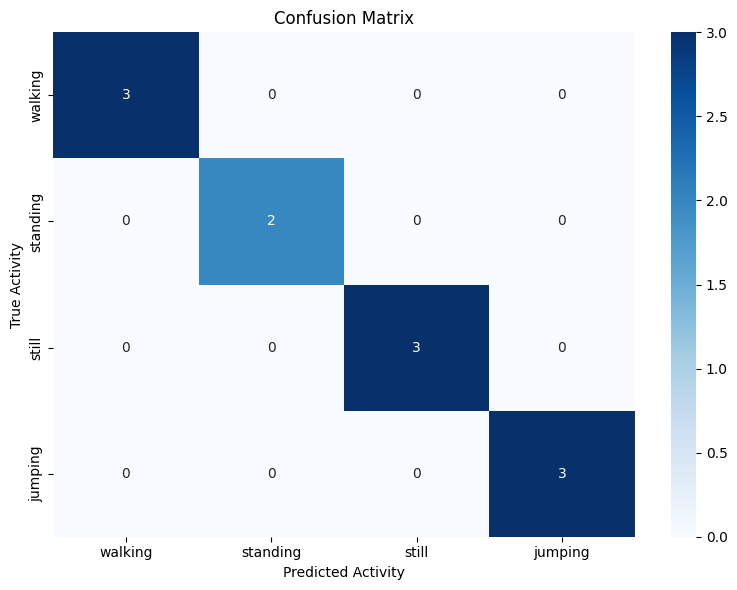

Confusion matrix saved!


In [10]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names,
            yticklabels=activity_names)
plt.title('Confusion Matrix')
plt.ylabel('True Activity')
plt.xlabel('Predicted Activity')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HMM_Project/confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

## Transition Matrices
The transition matrix for each activity shows the probability of moving
between hidden states within that activity. High diagonal values mean
the model tends to stay in the same state reflecting stable,
repetitive movements.

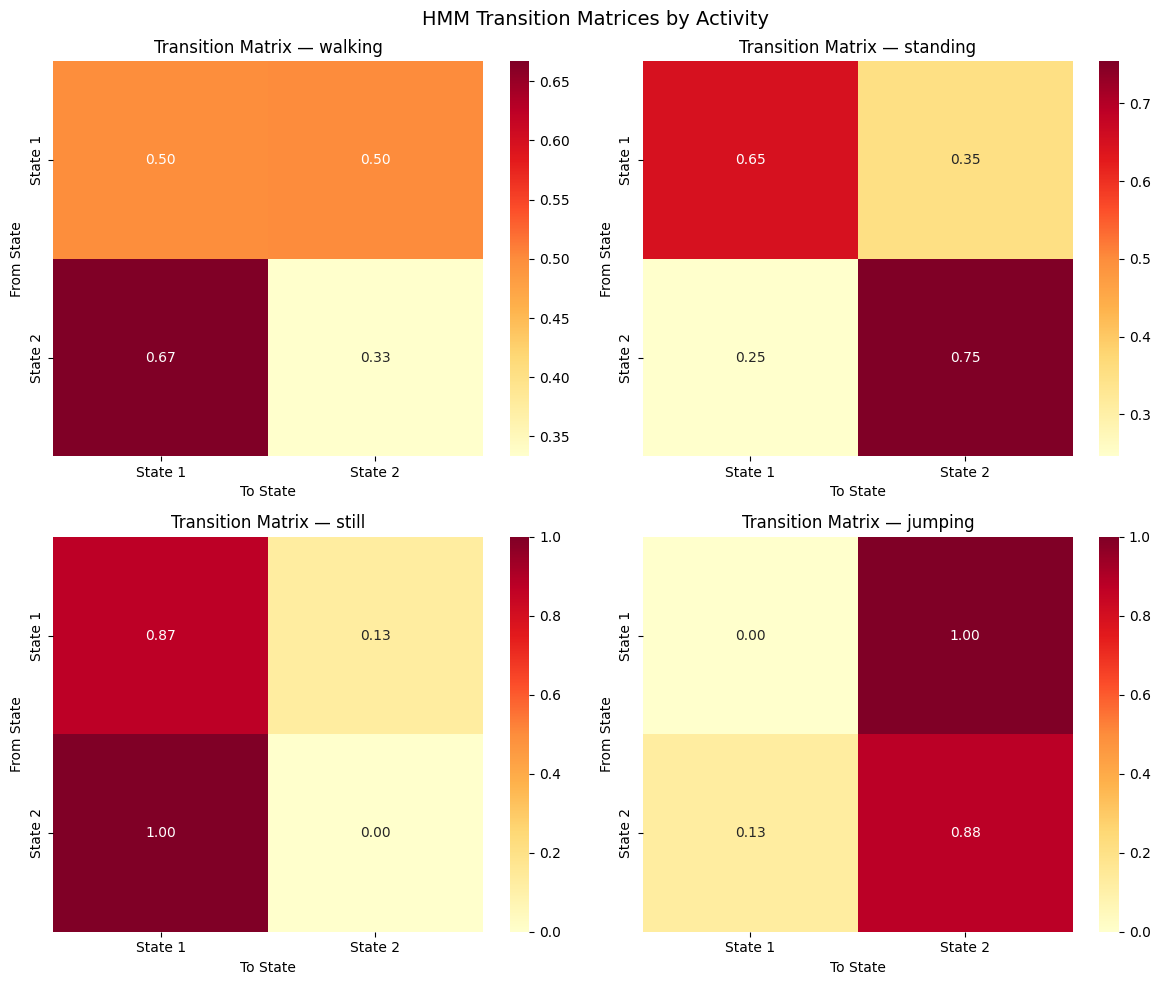

Transition matrices saved!


In [11]:
# Transition Matrix Heatmap for each activity model
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for label, activity in enumerate(activity_names):
    if label in models:
        trans_mat = models[label].transmat_
        sns.heatmap(trans_mat, annot=True, fmt='.2f', cmap='YlOrRd',
                    ax=axes[label],
                    xticklabels=[f'State {i+1}' for i in range(trans_mat.shape[0])],
                    yticklabels=[f'State {i+1}' for i in range(trans_mat.shape[0])])
        axes[label].set_title(f'Transition Matrix — {activity}')
        axes[label].set_ylabel('From State')
        axes[label].set_xlabel('To State')

plt.suptitle('HMM Transition Matrices by Activity', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HMM_Project/transition_matrices.png', dpi=150)
plt.show()
print("Transition matrices saved!")

## Emission Probabilities
The emission probability heatmaps show how strongly each hidden state
responds to each feature. Different activities show distinct patterns,
confirming that our features successfully distinguish between activities.

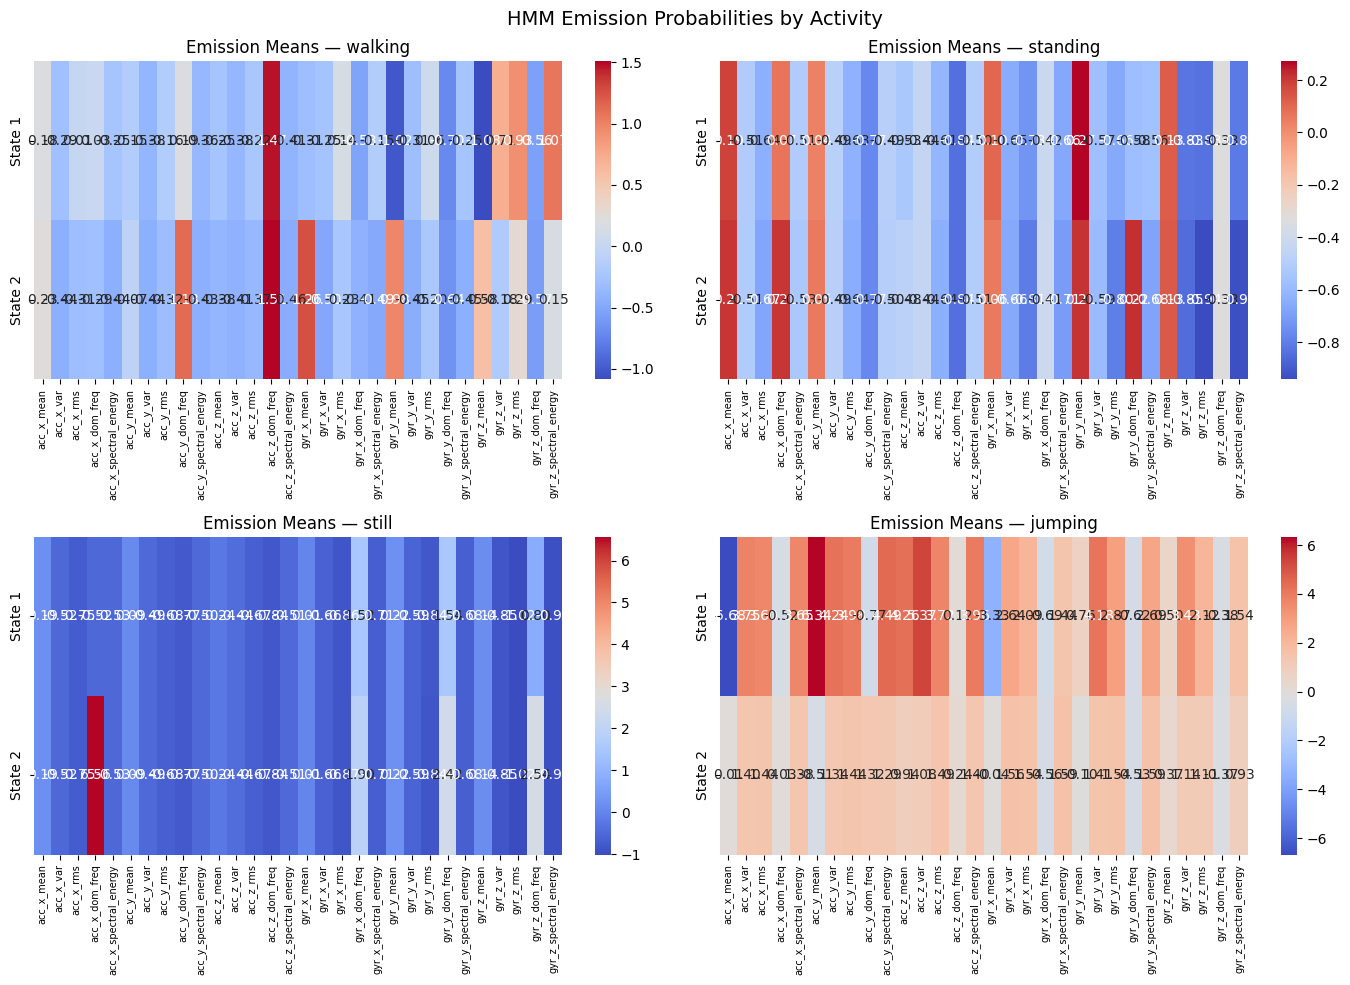

Emission probabilities saved!


In [12]:
# Emission Probabilities (Means) Heatmap
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

feature_labels = []
sensors = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
feat_types = ['mean', 'var', 'rms', 'dom_freq', 'spectral_energy']
for s in sensors:
    for f in feat_types:
        feature_labels.append(f'{s}_{f}')

for label, activity in enumerate(activity_names):
    if label in models:
        means = models[label].means_
        sns.heatmap(means, annot=True, fmt='.2f', cmap='coolwarm',
                    ax=axes[label],
                    xticklabels=feature_labels,
                    yticklabels=[f'State {i+1}' for i in range(means.shape[0])])
        axes[label].set_title(f'Emission Means — {activity}')
        axes[label].set_xticklabels(feature_labels, rotation=90, fontsize=7)

plt.suptitle('HMM Emission Probabilities by Activity', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HMM_Project/emission_probabilities.png', dpi=150)
plt.show()
print("Emission probabilities saved!")

## Performance Metrics
I compute sensitivity, specificity, and accuracy for each activity:
- Sensitivity: ability to correctly detect an activity when it occurs
- Specificity: ability to correctly reject an activity when it is not occurring
- Accuracy: overall correctness of the model

In [13]:
# Sensitivity, Specificity, Accuracy per activity
print("=" * 60)
print(f"{'Activity':<12} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}")
print("=" * 60)

for label, activity in enumerate(activity_names):
    TP = np.sum((y_test == label) & (y_pred == label))
    TN = np.sum((y_test != label) & (y_pred != label))
    FP = np.sum((y_test != label) & (y_pred == label))
    FN = np.sum((y_test == label) & (y_pred != label))

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    print(f"{activity:<12} {sensitivity*100:>11.1f}% {specificity*100:>11.1f}% {accuracy*100:>9.1f}%")

print("=" * 60)
print(f"\nOverall Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

Activity      Sensitivity  Specificity   Accuracy
walking            100.0%       100.0%     100.0%
standing           100.0%       100.0%     100.0%
still              100.0%       100.0%     100.0%
jumping            100.0%       100.0%     100.0%

Overall Accuracy: 100.00%


## Decoded Sequence Visualization
This plot shows the true activity labels versus the predicted labels
from Viterbi decoding across all test clips. Overlapping lines confirm
perfect classification.

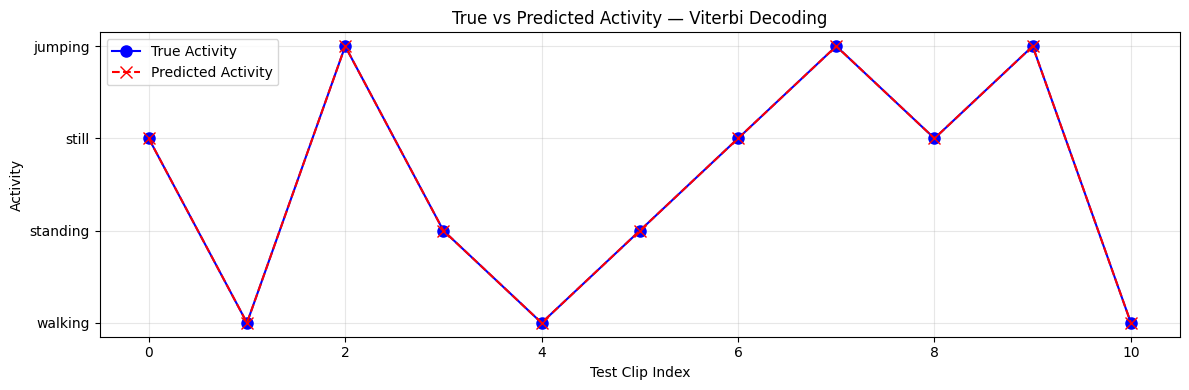

Decoded sequence plot saved!

All code complete! All visualizations saved to Google Drive.


In [14]:
# Decoded sequence plot
plt.figure(figsize=(12, 4))
plt.plot(y_test, 'bo-', label='True Activity', markersize=8)
plt.plot(y_pred, 'rx--', label='Predicted Activity', markersize=8)
plt.yticks([0, 1, 2, 3], activity_names)
plt.xlabel('Test Clip Index')
plt.ylabel('Activity')
plt.title('True vs Predicted Activity — Viterbi Decoding')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HMM_Project/decoded_sequence.png', dpi=150)
plt.show()
print("Decoded sequence plot saved!")
print("\nAll code complete! All visualizations saved to Google Drive.")

## Testing on Unseen Data
To evaluate generalization, two brand new recordings were collected
in a separate session never used during training:
- teste_walking_01: a fresh walking recording
- teste_standing_01: a fresh standing recording

These clips were processed and decoded using the trained HMM models
to test whether the model performs on completely new data.

In [20]:
# Remount drive to refresh files
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

# Test on unseen data again
test_clips = {
    'teste_walking_01': 0,
    'teste_standing_01': 1
}

print("Testing model on unseen data...")
print("=" * 50)

for folder_name, true_label in test_clips.items():
    clip_path = os.path.join(data_path, folder_name)
    clip = load_clip(clip_path)

    if clip is None:
        print(f"Could not load {folder_name}")
        continue

    features = extract_features(clip)
    features_scaled = scaler.transform(features.reshape(1, -1))
    predicted_label = predict_activity(features_scaled[0], models)

    true_activity = activity_names[true_label]
    predicted_activity = activity_names[predicted_label]
    correct = "✅ CORRECT" if true_label == predicted_label else "❌ WRONG"

    print(f"Clip: {folder_name}")
    print(f"True activity:      {true_activity}")
    print(f"Predicted activity: {predicted_activity}")
    print(f"Result: {correct}")
    print("-" * 50)

Mounted at /content/drive
Testing model on unseen data...
Clip: teste_walking_01
True activity:      walking
Predicted activity: walking
Result: ✅ CORRECT
--------------------------------------------------
Clip: teste_standing_01
True activity:      standing
Predicted activity: standing
Result: ✅ CORRECT
--------------------------------------------------


## Raw Sensor Data Visualization
Before building the model, I visualize raw accelerometer and gyroscope
signals for one sample clip from each activity. This helps us understand
how each activity looks as a signal and confirms that the four activities
produce distinct patterns that the HMM can learn to distinguish.

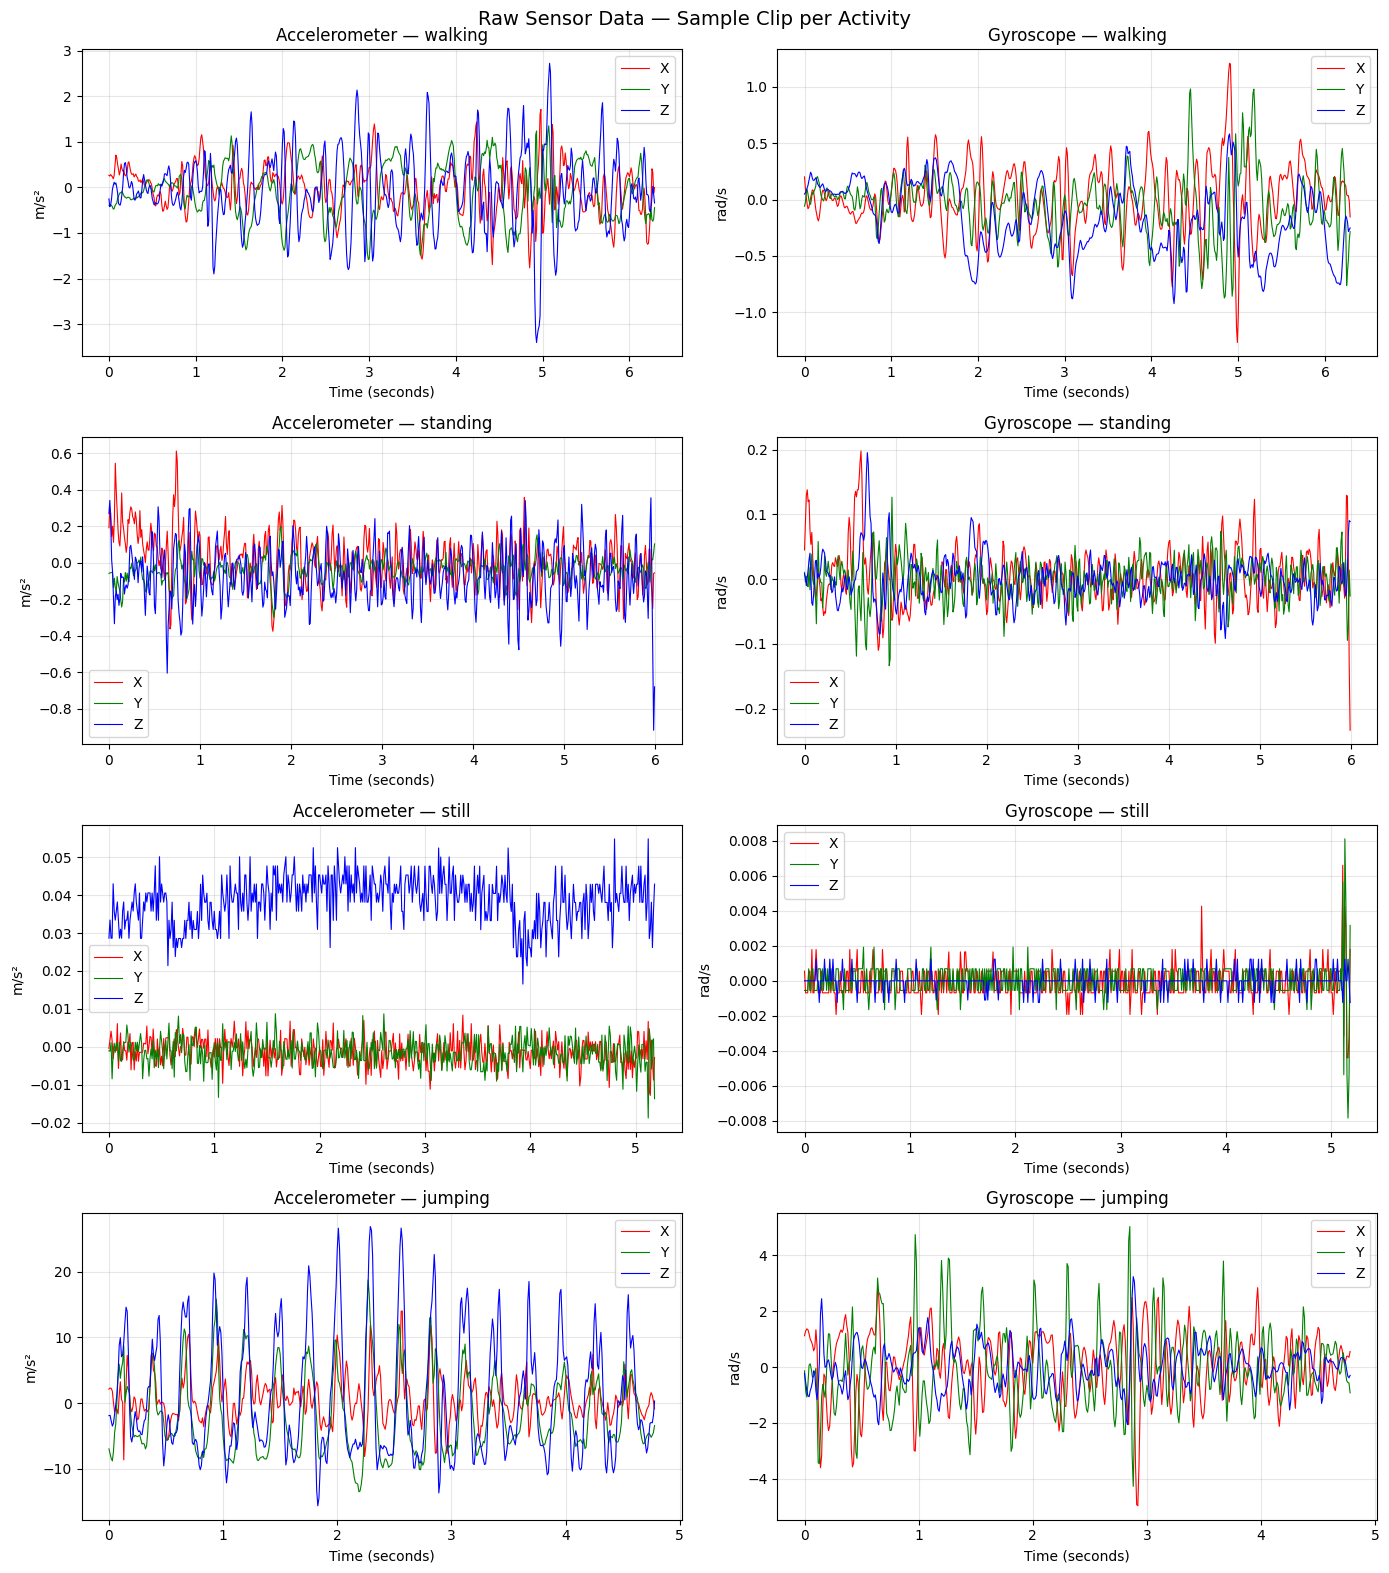

Raw data visualization saved!


In [21]:
# Raw Data Visualization — sample from each activity
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for idx, activity in enumerate(activity_names):
    # Get first clip of this activity
    for i, (clip, label) in enumerate(zip(all_data, all_labels)):
        if label == idx:
            sample_clip = clip
            break

    time = np.arange(len(sample_clip)) / 100  # 100Hz

    # Accelerometer (first 3 columns)
    axes[idx, 0].plot(time, sample_clip[:, 0], label='X', color='red', linewidth=0.8)
    axes[idx, 0].plot(time, sample_clip[:, 1], label='Y', color='green', linewidth=0.8)
    axes[idx, 0].plot(time, sample_clip[:, 2], label='Z', color='blue', linewidth=0.8)
    axes[idx, 0].set_title(f'Accelerometer — {activity}')
    axes[idx, 0].set_xlabel('Time (seconds)')
    axes[idx, 0].set_ylabel('m/s²')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)

    # Gyroscope (last 3 columns)
    axes[idx, 1].plot(time, sample_clip[:, 3], label='X', color='red', linewidth=0.8)
    axes[idx, 1].plot(time, sample_clip[:, 4], label='Y', color='green', linewidth=0.8)
    axes[idx, 1].plot(time, sample_clip[:, 5], label='Z', color='blue', linewidth=0.8)
    axes[idx, 1].set_title(f'Gyroscope — {activity}')
    axes[idx, 1].set_xlabel('Time (seconds)')
    axes[idx, 1].set_ylabel('rad/s')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.suptitle('Raw Sensor Data — Sample Clip per Activity', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HMM_Project/raw_data_visualization.png', dpi=150)
plt.show()
print("Raw data visualization saved!")